# 04 · Randomness and Probability

**Session 4 · Tue Sep 22 · 2 hours**

Probability has two definitions worth holding at once. The one that makes it *computable* is the
long-run frequency view: **the probability of an event is the fraction of times it happens if you
repeat the setup forever.**

You cannot repeat anything forever, but you can simulate 100,000 repetitions in a fraction of a
second — which is why every idea in this notebook gets demonstrated rather than asserted.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA = Path.cwd() / "data" if (Path.cwd() / "data").exists() else Path.cwd().parent / "data"
rng = np.random.default_rng(42)   # same seed => same numbers every time you run this

## 1 · Probability as a long-run frequency

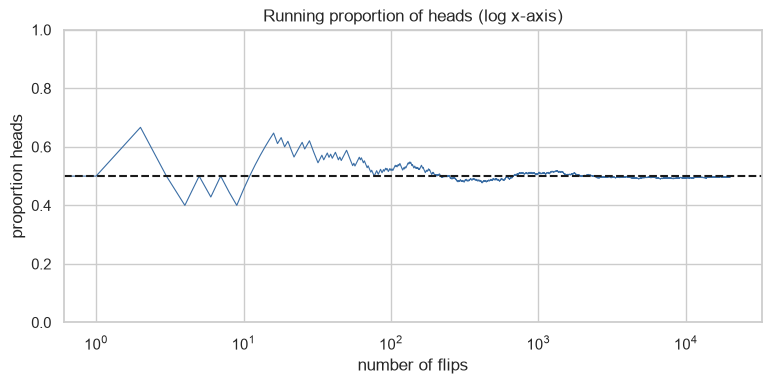

after     10 flips: 0.4000
after    100 flips: 0.5200
after  1,000 flips: 0.5090
after 20,000 flips: 0.4964


In [2]:
flips = rng.integers(0, 2, 20000)            # 0 = tails, 1 = heads
running = np.cumsum(flips) / np.arange(1, len(flips) + 1)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(running, lw=.8, color="#3b6ea5")
ax.axhline(0.5, color="k", ls="--")
ax.set_xscale("log")
ax.set_ylim(0, 1)
ax.set_title("Running proportion of heads (log x-axis)")
ax.set_xlabel("number of flips"); ax.set_ylabel("proportion heads")
plt.show()

for n in (10, 100, 1000, 20000):
    print(f"after {n:>6,} flips: {running[n-1]:.4f}")

### What that plot is actually saying

Early on the proportion swings wildly. By 20,000 flips it is pinned near 0.5.

**The crucial subtlety:** the coin has no memory and nothing "corrects" an imbalance. The proportion
settles because later flips *dilute* early deviations, not because the coin compensates for them. If
you are 10 heads ahead after 100 flips, you stay roughly 10 ahead — it just matters less and less as
a fraction.

Believing otherwise is the gambler's fallacy, and it is the same error as expecting a loan book to
"even out" after a bad quarter.

## 2 · numpy: vectorized thinking

The habit to build now: **describe the operation on the whole array**, do not loop over elements.
Loops in Python are slow and, more importantly, they read worse.

In [3]:
import time

n = 2_000_000
a = rng.normal(0, 1, n)

t0 = time.perf_counter()
loop_result = 0.0
for v in a[:200_000]:              # only 10% of the data, or it takes all morning
    loop_result += v * v
t_loop = (time.perf_counter() - t0) * 10       # scale up to compare fairly

t0 = time.perf_counter()
vec_result = np.sum(a * a)
t_vec = time.perf_counter() - t0

print(f"python loop (extrapolated): {t_loop:8.3f} s")
print(f"numpy vectorized:           {t_vec:8.3f} s")
print(f"speedup: roughly {t_loop/t_vec:,.0f}x")

python loop (extrapolated):    0.133 s
numpy vectorized:              0.002 s
speedup: roughly 87x


Same arithmetic, hundreds of times faster, and one line instead of three. `a * a` means "square every
element"; `np.sum` adds them. This is the idiom you will use constantly.

## 3 · The rules of probability, by simulation

Rather than trust the formulas, let's verify them. Two events on a single die roll:
`A` = roll is even, `B` = roll is 5 or more.

In [4]:
rolls = rng.integers(1, 7, 200_000)
A = (rolls % 2 == 0)          # 2, 4, 6
B = (rolls >= 5)              # 5, 6

print(f"P(A)         = {A.mean():.4f}   (theory 3/6 = 0.5000)")
print(f"P(B)         = {B.mean():.4f}   (theory 2/6 = 0.3333)")
print(f"P(A and B)   = {(A & B).mean():.4f}   (theory 1/6 = 0.1667)  <- only a 6")
print(f"P(A or B)    = {(A | B).mean():.4f}   (theory 4/6 = 0.6667)  <- 2,4,5,6")
print(f"P(not A)     = {(~A).mean():.4f}")
print()
print("addition rule:  P(A or B) = P(A) + P(B) - P(A and B)")
print(f"                {(A|B).mean():.4f} = {A.mean():.4f} + {B.mean():.4f} - {(A&B).mean():.4f}"
      f" = {A.mean()+B.mean()-(A&B).mean():.4f}")

P(A)         = 0.4997   (theory 3/6 = 0.5000)
P(B)         = 0.3342   (theory 2/6 = 0.3333)
P(A and B)   = 0.1669   (theory 1/6 = 0.1667)  <- only a 6
P(A or B)    = 0.6670   (theory 4/6 = 0.6667)  <- 2,4,5,6
P(not A)     = 0.5003

addition rule:  P(A or B) = P(A) + P(B) - P(A and B)
                0.6670 = 0.4997 + 0.3342 - 0.1669 = 0.6669


**Why you subtract the overlap:** adding `P(A)` and `P(B)` counts the outcome "6" twice, since a 6 is
both even and ≥5. Subtracting `P(A and B)` removes the double count. The formula is bookkeeping, not
insight — and now you have seen it be true rather than been told it.

## 4 · Conditional probability — the pipe `|`

`P(A | B)` is read *"the probability of A **given** B"*: restrict attention to the world where B
happened, then ask how often A happens there.

In code, "given B" is just **filtering**.

In [5]:
print(f"P(A)      = {A.mean():.4f}          <- all rolls")
print(f"P(A | B)  = {A[B].mean():.4f}          <- only rolls where B is true")
print()
print("A[B] means 'the values of A at the positions where B is true'. That is what")
print("conditioning IS: a filter. The pipe symbol means 'restrict the population to'.")

P(A)      = 0.4997          <- all rolls
P(A | B)  = 0.4995          <- only rolls where B is true

A[B] means 'the values of A at the positions where B is true'. That is what
conditioning IS: a filter. The pipe symbol means 'restrict the population to'.


### Independence

`A` and `B` are **independent** if knowing one tells you nothing about the other — that is,
`P(A | B) = P(A)`.

Here `P(A) = 0.50` and `P(A | B) = 0.50` too, so on this die "even" and "≥5" happen to *be*
independent: of the two outcomes {5, 6}, exactly one is even, which is the same one-in-two ratio as
the full die. Worth noticing that independence is a numerical accident of the setup, not something
you can eyeball from the descriptions. Let's construct a clearly dependent pair for contrast.

In [6]:
C = (rolls >= 4)              # {4, 5, 6} -- evens are 4 and 6, so 2 of 3
print(f"P(A)      = {A.mean():.4f}")
print(f"P(A | C)  = {A[C].mean():.4f}   <- knowing C CHANGES the answer => DEPENDENT")
print()
high = (rolls == 6)
print(f"P(high)          = {high.mean():.4f}")
print(f"P(high | B)      = {high[B].mean():.4f}   <- B triples it => strongly dependent")

P(A)      = 0.4997
P(A | C)  = 0.6659   <- knowing C CHANGES the answer => DEPENDENT

P(high)          = 0.1669
P(high | B)      = 0.4995   <- B triples it => strongly dependent


## Your turn

**Exercise 1.** Simulate 100,000 rolls of **two** dice. What is the probability the total is 7? And
given that the first die shows a 4, what is it then?

In [7]:
# your code here

In [ ]:
d1 = rng.integers(1, 7, 100_000)
d2 = rng.integers(1, 7, 100_000)
total = d1 + d2

print(f"P(total = 7)            = {np.mean(total == 7):.4f}   (theory 6/36 = 0.1667)")
print(f"P(total = 7 | d1 = 4)   = {np.mean(total[d1 == 4] == 7):.4f}   (theory 1/6 = 0.1667)")
# Equal -- because whatever the first die shows, exactly one value of the second die
# completes a 7. A nice case where conditioning changes nothing.

**Exercise 2.** Using the same two dice: `P(total >= 10)`, and `P(total >= 10 | d1 >= 5)`. Are those
events independent?

In [9]:
# your code here

In [ ]:
print(f"P(total >= 10)             = {np.mean(total >= 10):.4f}")
print(f"P(total >= 10 | d1 >= 5)   = {np.mean(total[d1 >= 5] >= 10):.4f}")
# Far higher when the first die is large -> clearly DEPENDENT. You cannot reach 10
# without a big first die, so learning d1 >= 5 is very informative.

## What you did today

- Probability as long-run frequency — and why the "law of averages" does not mean the coin corrects itself.
- Vectorized numpy instead of loops.
- Verified the addition rule by simulation rather than accepting it.
- **Conditioning is filtering.** `P(A | B)` = "compute A only among the rows where B is true."

**Next:** `05_bayes_by_simulation.ipynb` — where conditioning becomes genuinely counterintuitive and
where most people's intuition breaks. This is the single most important notebook in the set.